In [3]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import sys
sys.path.append("../workflow/scripts")
from helpers import ensure_parent

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
nucnorm_coarse = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
outdir = "/gpfs/commons/groups/knowles_lab/data/PsychGen/analysis/clorinn/cross_validation"

In [5]:
cv_metrics = [f"{outdir}/metrics/nnm_cv_metrics_r{r}.json" for r in nucnorm_coarse]
rows = []
for metric_file in cv_metrics:
    with open(metric_file) as handle:
        rows.append(json.load(handle))

df = pd.DataFrame(rows)
df

,heldout_mae,heldout_mse,heldout_rmse,max_iter,method,n_heldout,n_iter,nucnorm
0,1.168244,2.972778,1.724175,4000,nnm,472701,3,1.0
1,1.168172,2.972369,1.724056,4000,nnm,472701,3,2.0
2,1.168016,2.971534,1.723814,4000,nnm,472701,4,4.0
3,1.167715,2.969881,1.723334,4000,nnm,472701,3,8.0
4,1.167103,2.966576,1.722375,4000,nnm,472701,4,16.0
5,1.165911,2.960060,1.720483,4000,nnm,472701,6,32.0
6,1.162858,2.946342,1.716491,4000,nnm,472701,5,64.0
7,1.156235,2.918661,1.708409,4000,nnm,472701,6,128.0
8,1.143284,2.865667,1.692828,4000,nnm,472701,5,256.0
9,1.120637,2.771007,1.664634,4000,nnm,472701,9,512.0


In [6]:
X_dict = {}
for r in nucnorm_coarse:
    model_file = f"{outdir}/models/nnm_cv_model_r{r}.pkl"
    with open(model_file, 'rb') as handle:
        model = pickle.load(handle)
        X_dict[r] = model['X_']

In [7]:
def compute_svds(X_dict):
    svd_by_r = {}
    for r in sorted(X_dict):
        X = np.asarray(X_dict[r], dtype=float)
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        svd_by_r[float(r)] = {"U": U, "s": s, "Vt": Vt}
    return svd_by_r


def save_svds(svd_by_r, outdir):
    outdir = Path(outdir)
    ensure_parent(outdir)

    ranks = []
    for r, decomp in sorted(svd_by_r.items()):
        fname = outdir / f"svd_r_{int(r)}.npz"
        np.savez_compressed(fname, U=decomp["U"], s=decomp["s"], Vt=decomp["Vt"])
        ranks.append(r)

    np.savez_compressed(outdir / "index.npz", rank=np.array(ranks, dtype=float))
    
def read_svds(outdir="svd_by_r"):
    outdir = Path(outdir)
    index_file = outdir / "index.npz"
    with np.load(index_file) as data:
        ranks = data["rank"]

    svd_by_r = {}
    for r in ranks:
        fname = outdir / f"svd_r_{int(r)}.npz"
        with np.load(fname) as data:
            svd_by_r[float(r)] = {
                "U": data["U"],
                "s": data["s"],
                "Vt": data["Vt"],
            }
    return svd_by_r

# svd_by_rank = compute_svds(X_dict)
# save_svds(svd_by_rank, f"{outdir}/svd_by_ranks")
svd_by_rank = read_svds(f"{outdir}/svd_by_ranks")

In [8]:
def proj_dist(U1, U2, k):
    """
    Normalized projection distance between top-k subspaces.
    Returns a number in [0, 1].
    """
    U1k = U1[:, :k]
    U2k = U2[:, :k]
    overlap = np.linalg.norm(U1k.T @ U2k, ord="fro") ** 2
    val = max(0.0, 1.0 - overlap / k)
    return np.sqrt(val)

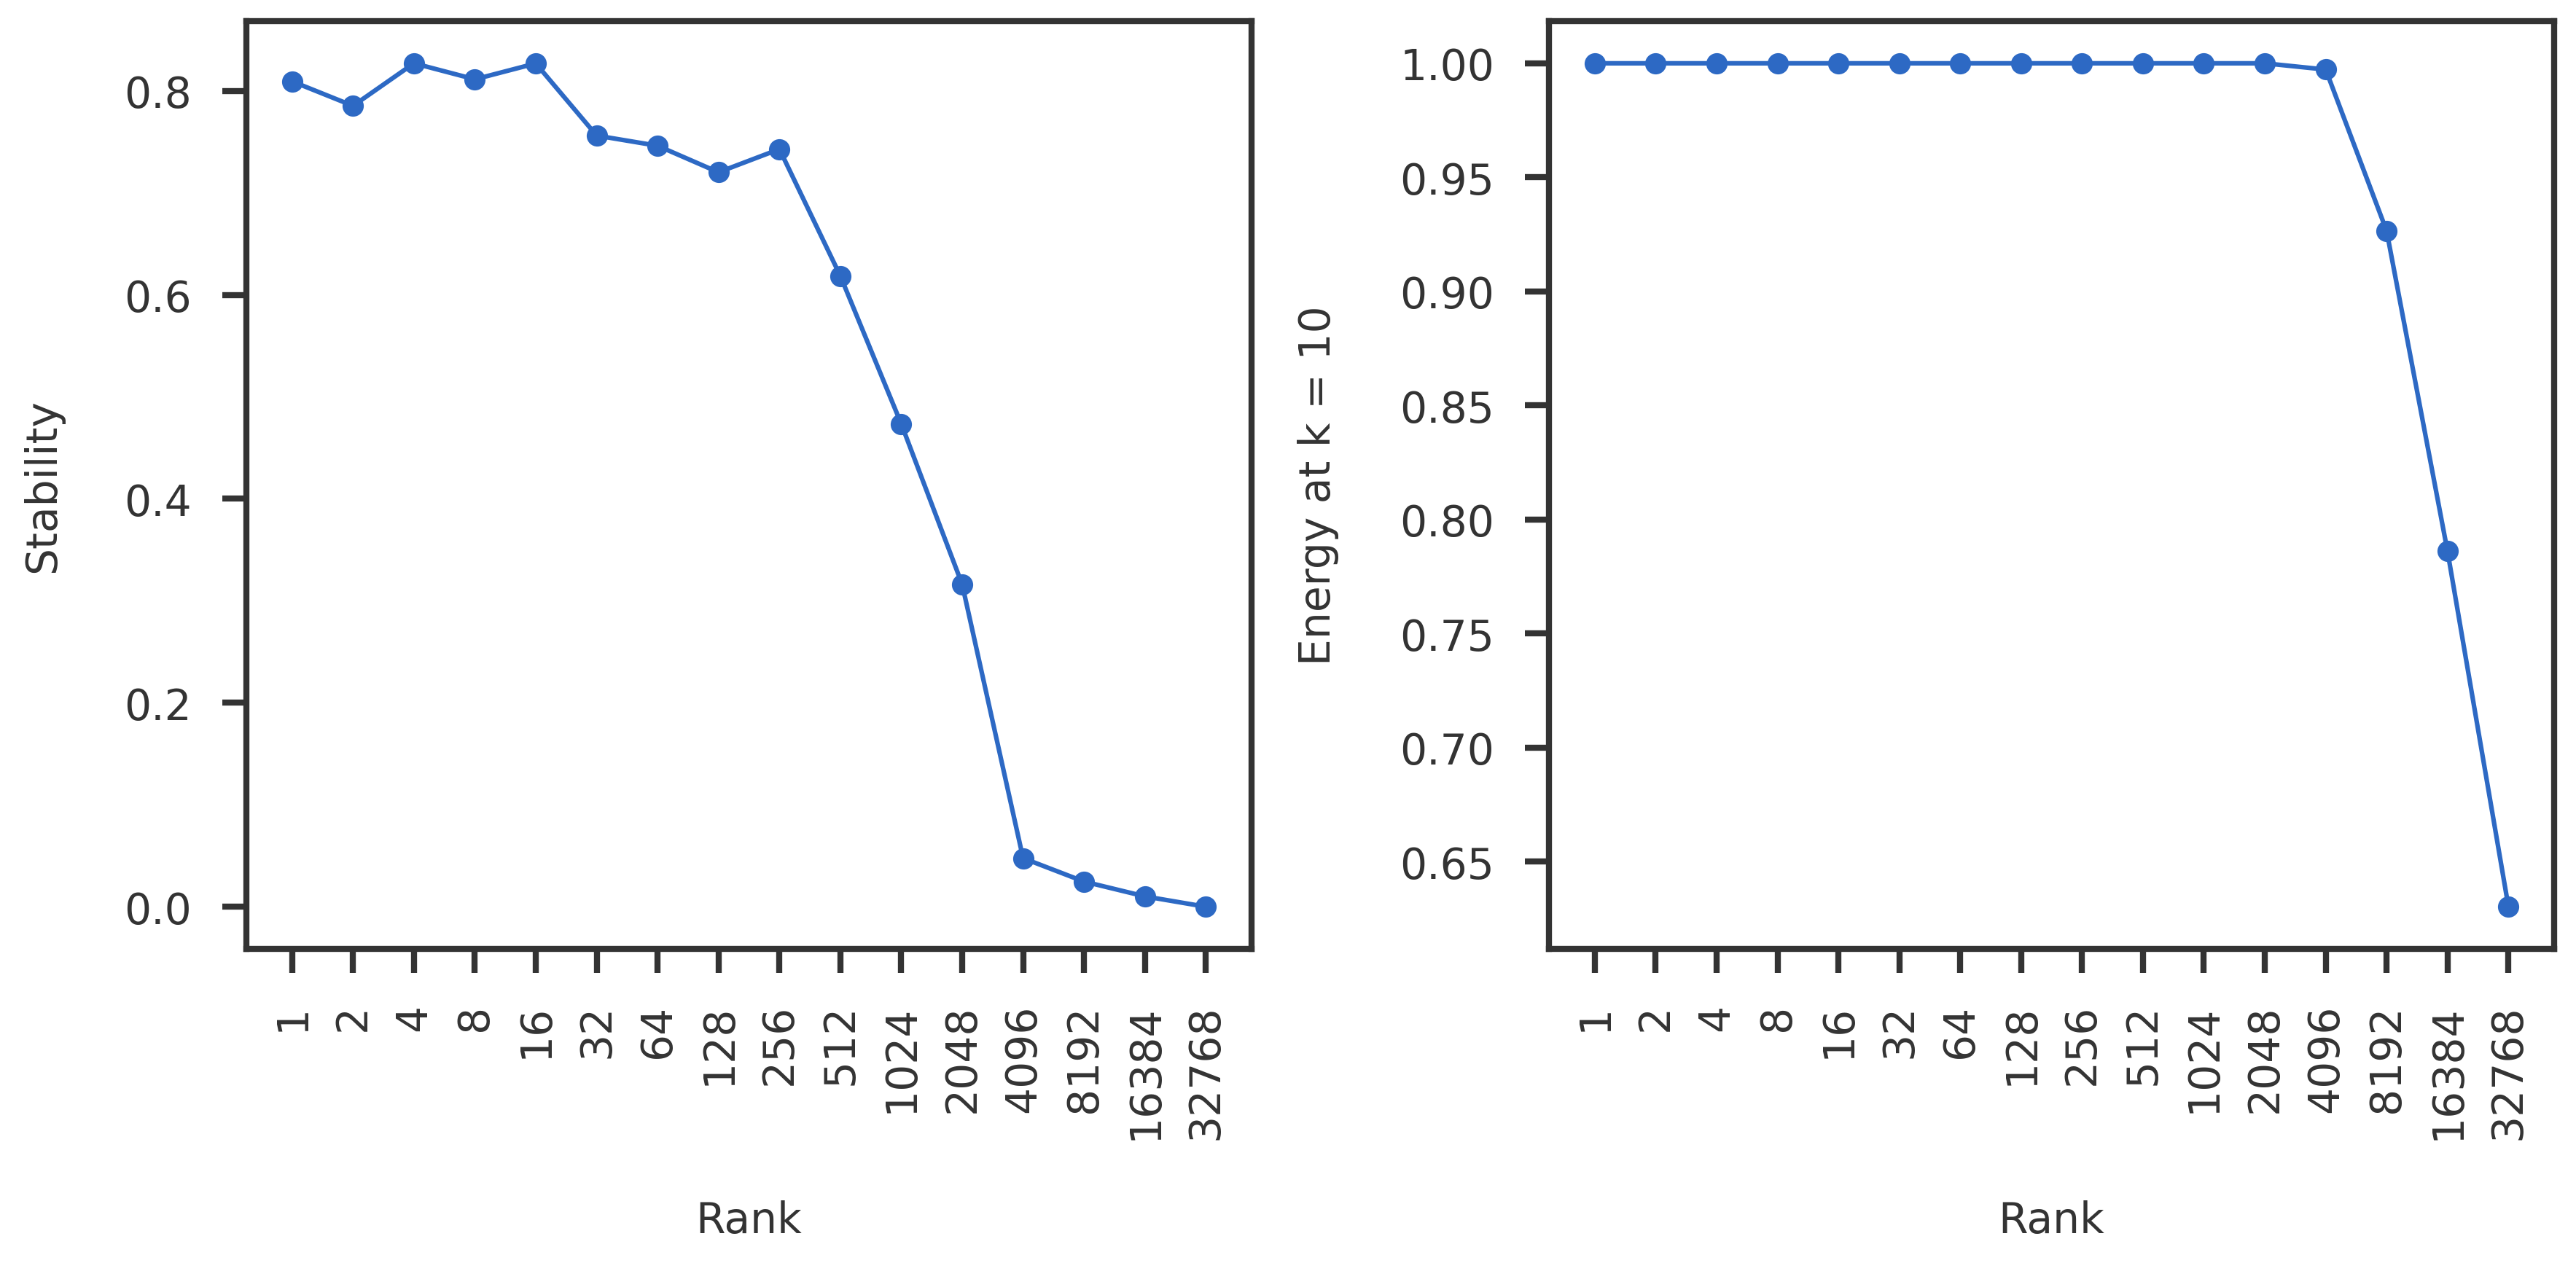

In [9]:
k = 10

stability = {}
energy = {}
ref_U = svd_by_rank[nucnorm_coarse[- 1]]['U']
for i, r in enumerate(nucnorm_coarse):
    U = svd_by_rank[r]['U']
    # prev_U = svd_by_rank[nucnorm_coarse[i - 1]]['U']
    stability[r] = proj_dist(U, ref_U, k)
    s2 = svd_by_rank[r]['s'] ** 2
    cum_energy = np.cumsum(s2) / np.sum(s2)
    energy[r] = cum_energy[k]

fig = plt.figure(figsize = (12, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.plot(np.arange(len(stability)), stability.values(), 'o-')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Stability')
ax1.set_xticks(np.arange(len(stability)))
ax1.set_xticklabels(stability.keys(), rotation=90)

ax2.plot(np.arange(len(energy)), energy.values(), 'o-')
ax2.set_xlabel('Rank')
ax2.set_ylabel(f"Energy at k = {k}")
ax2.set_xticks(np.arange(len(energy)))
ax2.set_xticklabels(energy.keys(), rotation=90)
plt.tight_layout()
plt.show()

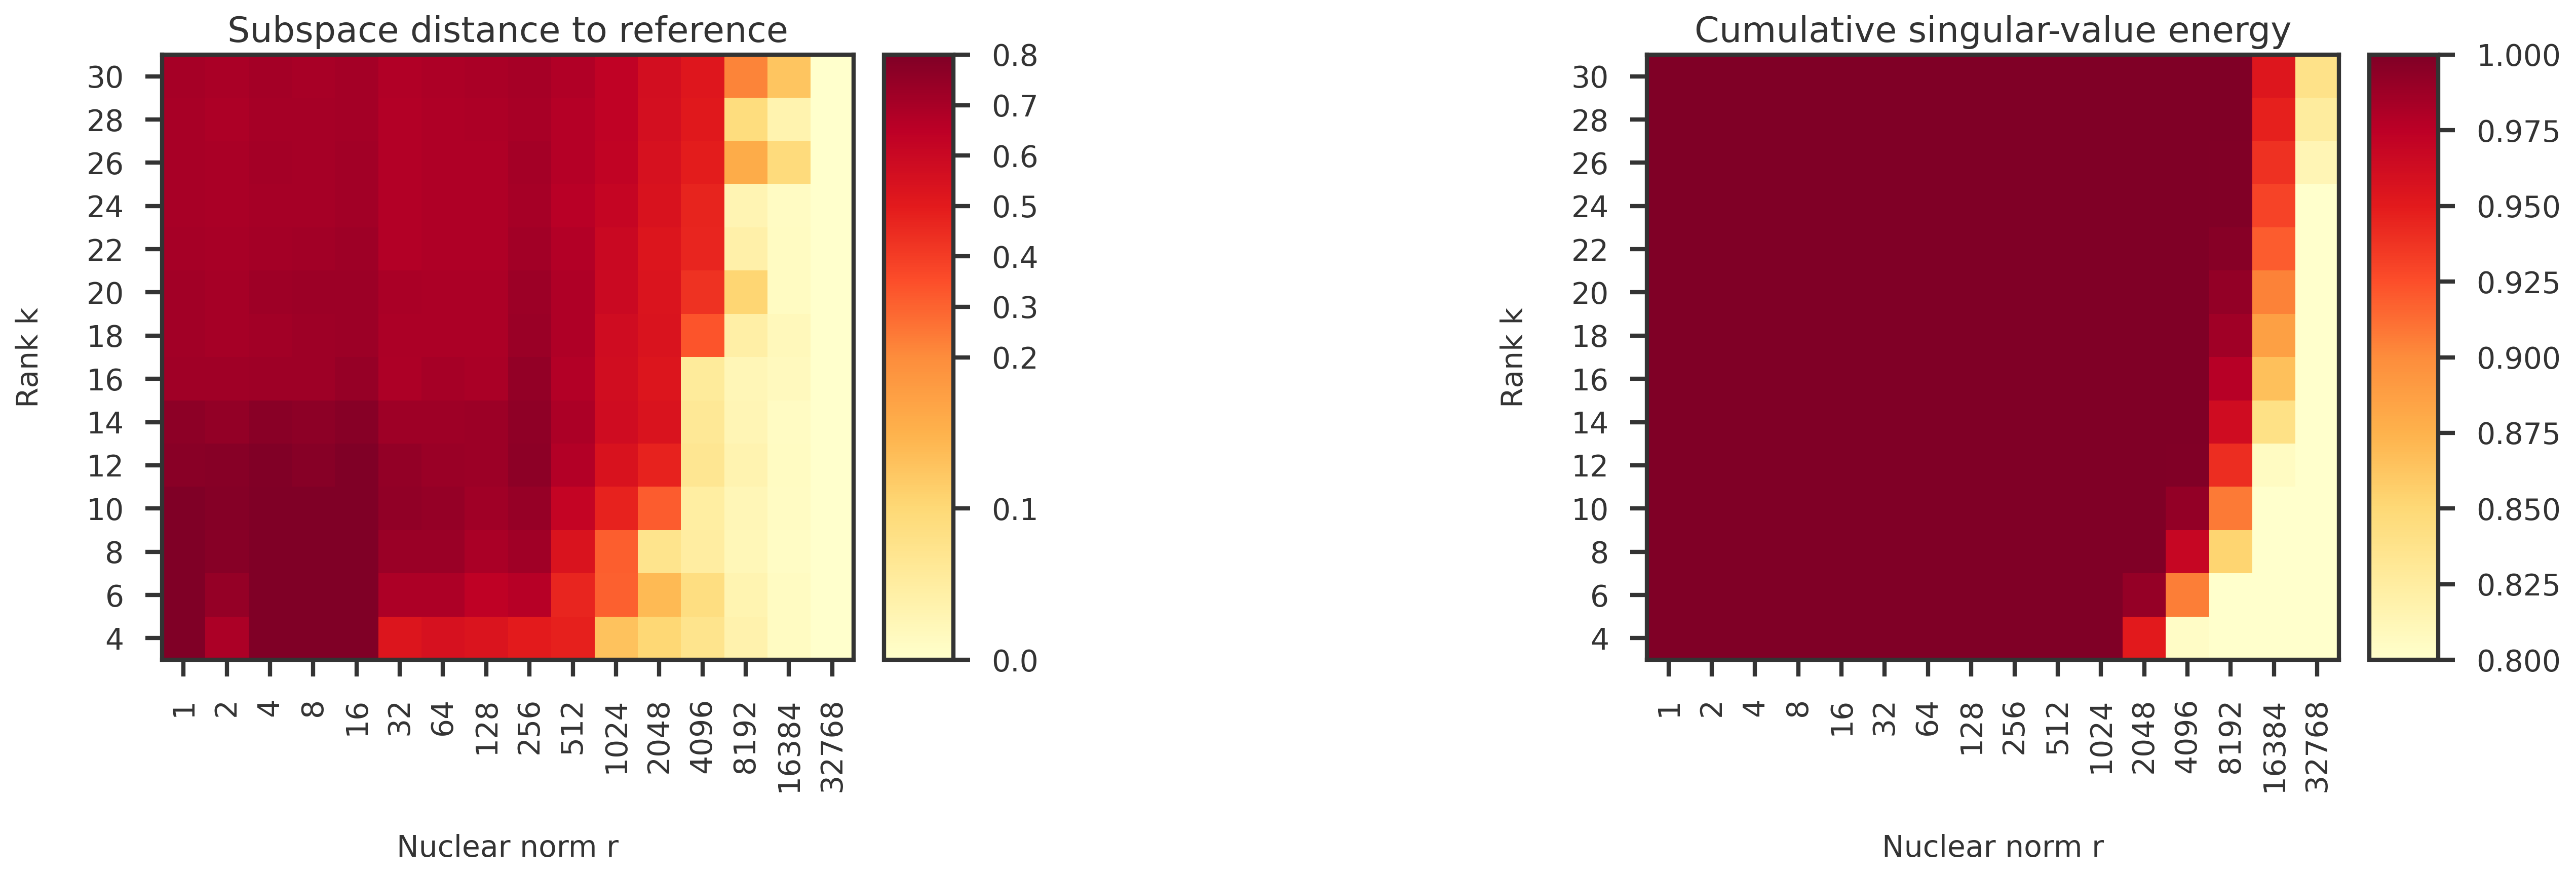

In [10]:
def build_rank_k_grid(svd_by_rank, ranks, k_list):
    stability = np.full((len(ranks), len(k_list)), np.nan)
    energy = np.full((len(ranks), len(k_list)), np.nan)
    eigengap = np.full((len(ranks), len(k_list)), np.nan)

    ref_U = svd_by_rank[ranks[- 1]]['U']

    for i, r in enumerate(ranks):
        U = svd_by_rank[float(r)]["U"]
        s = svd_by_rank[float(r)]["s"]

        s2 = s**2
        cum_energy = np.cumsum(s2) / np.sum(s2)

        for j, k in enumerate(k_list):
            stability[i, j] = proj_dist(U, ref_U, k)
            energy[i, j] = cum_energy[k - 1]
            eigengap[i, j] = np.inf if s[k] == 0 else s[k - 1] / s[k]
            
    return stability, energy, eigengap
                
kmax = 30
k_list = [k for k in range(4, kmax + 1, 2)]
rank_list = sorted(svd_by_rank.keys())
stability, energy, eigengap = build_rank_k_grid(svd_by_rank, rank_list, k_list)

fig = plt.figure(figsize = (20, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

def plot_heatmap(ax, X, rank_list, k_list, vmin = 0, vcenter = 0.9, vmax = 1.0):
    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()
    cmap1.set_bad("w")
    norm1 = mpl_colors.TwoSlopeNorm(vmin = vmin, vcenter = vcenter, vmax = vmax)
    im1 = ax.imshow(X.T, cmap = cmap1, norm = norm1, origin = 'lower')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="10%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction = 0.1)

    ax.set_xlabel("Nuclear norm r")
    ax.set_ylabel("Rank k")
    ax.set_yticks(np.arange(len(k_list)))
    ax.set_yticklabels([str(int(k)) for k in k_list])
    ax.set_xticks(np.arange(len(rank_list)))
    ax.set_xticklabels([str(int(r)) for r in rank_list], rotation=90)
    
    return

plot_heatmap(ax1, stability, rank_list, k_list, vmin = 0, vcenter = 0.2, vmax = 0.8)
ax1.set_title("Subspace distance to reference")

plot_heatmap(ax2, energy, rank_list, k_list, vmin = 0.8, vcenter = 0.9, vmax = 1.0)
ax2.set_title("Cumulative singular-value energy")

plt.tight_layout()
plt.show()

In [11]:
rows

[{'heldout_mae': 1.1682441902786782,
  'heldout_mse': 2.9727784028676423,
  'heldout_rmse': 1.7241747019567484,
  'max_iter': 4000,
  'method': 'nnm',
  'n_heldout': 472701,
  'n_iter': 3,
  'nucnorm': 1.0},
 {'heldout_mae': 1.1681720315086388,
  'heldout_mse': 2.9723687433679618,
  'heldout_rmse': 1.7240558991424733,
  'max_iter': 4000,
  'method': 'nnm',
  'n_heldout': 472701,
  'n_iter': 3,
  'nucnorm': 2.0},
 {'heldout_mae': 1.1680163575557072,
  'heldout_mse': 2.971533778723432,
  'heldout_rmse': 1.7238137308663695,
  'max_iter': 4000,
  'method': 'nnm',
  'n_heldout': 472701,
  'n_iter': 4,
  'nucnorm': 4.0},
 {'heldout_mae': 1.16771471568041,
  'heldout_mse': 2.969880878669767,
  'heldout_rmse': 1.7233342330116252,
  'max_iter': 4000,
  'method': 'nnm',
  'n_heldout': 472701,
  'n_iter': 3,
  'nucnorm': 8.0},
 {'heldout_mae': 1.167103289218761,
  'heldout_mse': 2.9665760985809464,
  'heldout_rmse': 1.7223751329431538,
  'max_iter': 4000,
  'method': 'nnm',
  'n_heldout': 472701,